### Задача 4
Смоделировать выборку объема 1000 из дискретного распределения на множестве цифр 0, 1, 2, ..., 9 с заданными весами. Оптимизировать алгоритм, упорядочив веса.

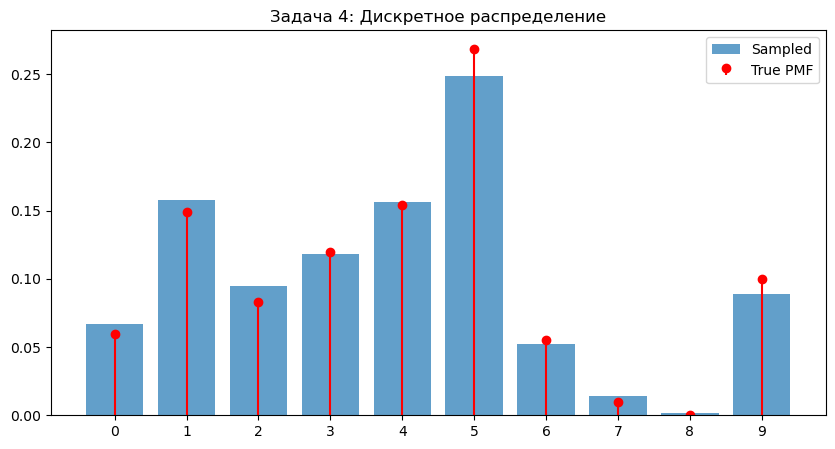

In [11]:
import numpy as np
import matplotlib.pyplot as plt

values = np.arange(10)
weights = np.array([0.12, 0.3, 0.167, 0.24, 0.31, 0.54, 0.111, 0.02, 0.001, 0.2])

# Нормировка весов
probs = weights / weights.sum()

sorted_indices = np.argsort(probs)[::-1]
sorted_probs = probs[sorted_indices]
sorted_values = values[sorted_indices]

# Кумулятивная сумма для выборки
cumsum_probs = np.cumsum(sorted_probs)

# Генерация выборки
n_samples = 1000
u = np.random.rand(n_samples)
# searchsorted находит индексы, куда попадают случайные числа u
sample_indices = np.searchsorted(cumsum_probs, u)
samples = sorted_values[sample_indices]

plt.figure(figsize=(10, 5))
plt.hist(samples, bins=np.arange(11)-0.5, rwidth=0.8, density=True, alpha=0.7, label='Sampled')
plt.stem(values, probs, linefmt='r-', markerfmt='ro', basefmt=' ', label='True PMF')
plt.xticks(values)
plt.title('Задача 4: Дискретное распределение')
plt.legend()
plt.show()

### Задача 5
Смоделировать выборку размера 1000 из распределения $Exp(\lambda)$ с помощью метода Inverse transform.

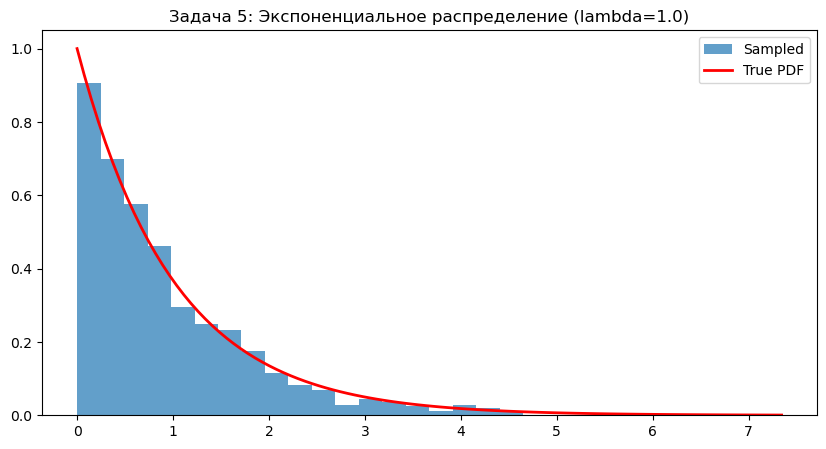

In [13]:
lam = 1.0

# Поскольку 1-u тоже распределено как U[0,1], можно использовать x = -ln(u) / lambda
u = np.random.rand(1000)
exp_samples = -np.log(u) / lam

plt.figure(figsize=(10, 5))
plt.hist(exp_samples, bins=30, density=True, alpha=0.7, label='Sampled')

# Точная плотность
x_axis = np.linspace(0, np.max(exp_samples), 100)
pdf_true = lam * np.exp(-lam * x_axis)
plt.plot(x_axis, pdf_true, 'r', linewidth=2, label='True PDF')

plt.title(f'Задача 5: Экспоненциальное распределение (lambda={lam})')
plt.legend()
plt.show()

### Задача 6
Метод accept-reject для плотности, пропорциональной $e^x \cos^2 x$ на отрезке $[-\pi/2, \pi/2]$.

**Обоснование метода:** Метод Accept-Reject работает, генерируя точки равномерно в области, ограничивающей график плотности целевого распределения. Точки, попавшие под график ($u < f(x)/Mg(x)$), принимаются, что обеспечивает плотность вероятности, пропорциональную $f(x)$.

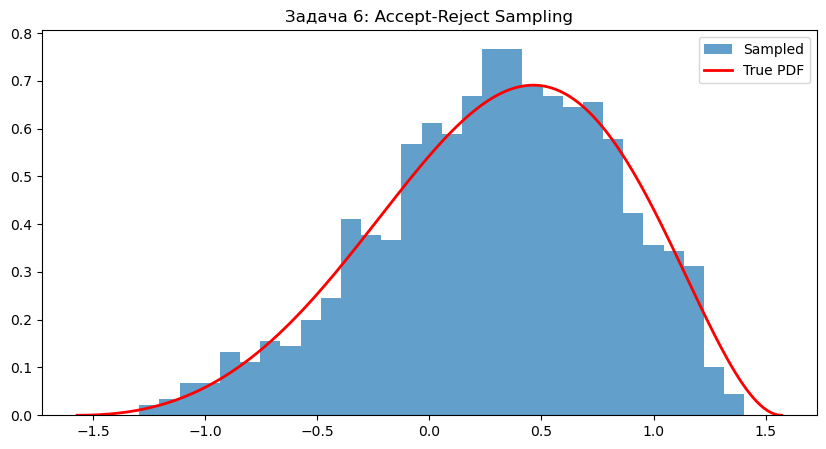

In [15]:
def target_func(x):
    return np.exp(x) * (np.cos(x)**2)

a, b = -np.pi/2, np.pi/2

# Оценка константы M. Максимум e^x на интервале равен e^(pi/2) approx 4.81.
# cos^2(x) <= 1. Значит f(x) <= e^(pi/2).
M = np.exp(b)

samples_ar = []
n_required = 1000

while len(samples_ar) < n_required:
    x_prop = np.random.uniform(a, b)
    # Генерируем y равномерно от 0 до M
    y_prop = np.random.uniform(0, M)
    
    if y_prop <= target_func(x_prop):
        samples_ar.append(x_prop)

samples_ar = np.array(samples_ar)

plt.figure(figsize=(10, 5))
plt.hist(samples_ar, bins=30, density=True, alpha=0.7, label='Sampled')

# Точная плотность
from scipy.integrate import quad
norm_const, _ = quad(target_func, a, b)

x_vals = np.linspace(a, b, 200)
plt.plot(x_vals, target_func(x_vals) / norm_const, 'r', linewidth=2, label='True PDF')

plt.title('Задача 6: Accept-Reject Sampling')
plt.legend()
plt.show()

### Задача 7
Смоделировать выборку из 500 точек равномерно распределенных внутри треугольника без использования метода отбора.

Используем свойство: $P = (1 - \sqrt{r_1}) A + \sqrt{r_1} (1 - r_2) B + \sqrt{r_1} r_2 C$, где $r_1, r_2 \sim U[0, 1]$.

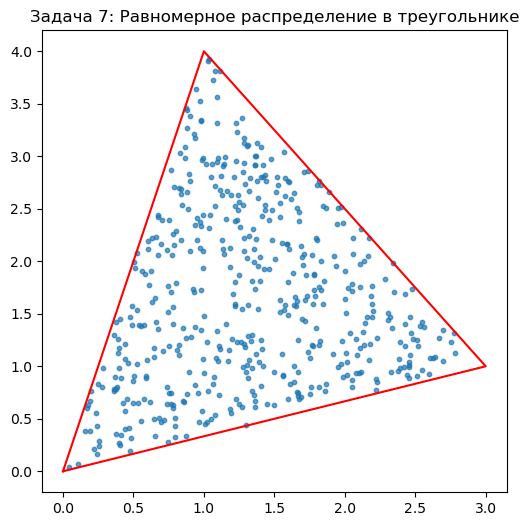

In [4]:
# Вершины треугольника (произвольные)
A = np.array([0, 0])
B = np.array([3, 1])
C = np.array([1, 4])

n_points = 500
r1 = np.random.rand(n_points)
r2 = np.random.rand(n_points)

# Барицентрические координаты для равномерного распределения
sqrt_r1 = np.sqrt(r1)
coef_A = 1 - sqrt_r1
coef_B = sqrt_r1 * (1 - r2)
coef_C = sqrt_r1 * r2

points_tri = np.outer(coef_A, A) + np.outer(coef_B, B) + np.outer(coef_C, C)

plt.figure(figsize=(6, 6))
plt.scatter(points_tri[:, 0], points_tri[:, 1], s=10, alpha=0.7)
# Рисуем сам треугольник
triangle = np.array([A, B, C, A])
plt.plot(triangle[:, 0], triangle[:, 1], 'r-')
plt.title('Задача 7: Равномерное распределение в треугольнике')
plt.show()

### Задача 8
Смоделировать выборку из 500 точек равномерно распределенных внутри единичного круга.

Используем полярные координаты: $\phi \sim U[0, 2\pi]$, $r = \sqrt{U[0, 1]}$.

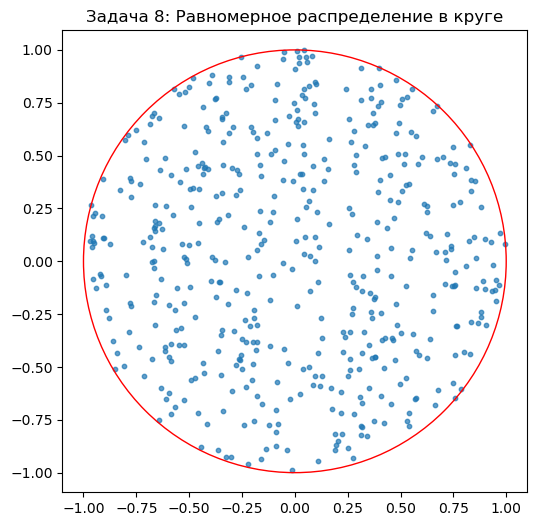

In [16]:
n_circle = 500
phi = np.random.uniform(0, 2*np.pi, n_circle)
r = np.sqrt(np.random.rand(n_circle))

x_circle = r * np.cos(phi)
y_circle = r * np.sin(phi)

plt.figure(figsize=(6, 6))
plt.scatter(x_circle, y_circle, s=10, alpha=0.7)
circle_plot = plt.Circle((0, 0), 1, color='r', fill=False)
plt.gca().add_patch(circle_plot)
plt.axis('equal')
plt.title('Задача 8: Равномерное распределение в круге')
plt.show()

### Задача 9
Модифицированный Box-Muller (Polar method) и моделирование двумерного гауссовского распределения.

**Модификация:** Вместо вычисления $\cos$ и $\sin$ через тригонометрические функции, генерируем точку $(u, v)$ равномерно в единичном круге. Тогда $s = u^2 + v^2$. Значения $\frac{u}{\sqrt{s}}$ и $\frac{v}{\sqrt{s}}$ играют роль косинуса и синуса случайного угла.

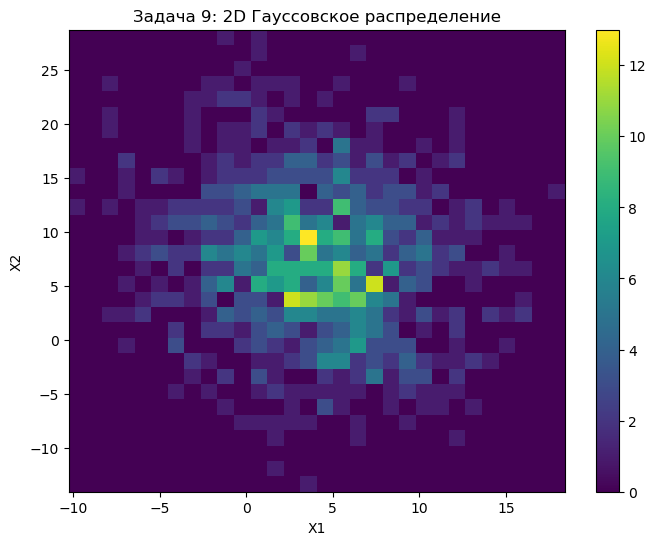

Выборочное среднее:
 [4.03770532 7.2742933 ]
Истинное среднее:
 [4 7]

Выборочная ковариация:
 [[20.38918933 -4.45345697]
 [-4.45345697 42.89189608]]
Истинная ковариация:
 [[20 -4]
 [-4 40]]


In [17]:
def box_muller_polar(n):
    z1 = []
    z2 = []
    while len(z1) < n:
        u = np.random.uniform(-1, 1)
        v = np.random.uniform(-1, 1)
        s = u**2 + v**2
        if 0 < s <= 1:
            # Преобразование Марсальи
            factor = np.sqrt(-2 * np.log(s) / s)
            z1.append(u * factor)
            z2.append(v * factor)
            
    return np.array(z1[:n]), np.array(z2[:n])

# Генерация стандартного нормального распределения
n_gauss = 1000
z1, z2 = box_muller_polar(n_gauss)
Z = np.vstack([z1, z2]) # Shape (2, 1000)

# Целевые параметры
mu = np.array([4, 7])
Sigma = np.array([[20, -4], [-4, 40]])

# Преобразование: X = mu + L * Z
L = np.linalg.cholesky(Sigma)
X = mu[:, np.newaxis] + L @ Z
X = X.T # Shape (1000, 2)

plt.figure(figsize=(8, 6))
plt.hist2d(X[:, 0], X[:, 1], bins=30)
plt.colorbar()
plt.title('Задача 9: 2D Гауссовское распределение')
plt.xlabel('X1')
plt.ylabel('X2')
plt.show()

# Проверка статистик
print("Выборочное среднее:\n", np.mean(X, axis=0))
print("Истинное среднее:\n", mu)
print("\nВыборочная ковариация:\n", np.cov(X, rowvar=False))
print("Истинная ковариация:\n", Sigma)